[Arrythmia data set](https://archive.ics.uci.edu/dataset/5/arrhythmia) from the UCI Machine Learning Repository.

In [1]:
import pandas as pd
import numpy as np

labels=list(range(279)) + ['class']

df = pd.read_csv('/Users/irene/GitHub/BIG-DATA-TOOLS/Execises/arrhythmia.csv', names=labels)

# dataset info in arrhythmia.names

In [2]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,class
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


In [3]:
# TO DO
    # analysis on the dataset
    # managing missing values
    # standardization and normalization
    # PCA perform, what is the optimal number of components? why?

<Axes: xlabel='class'>

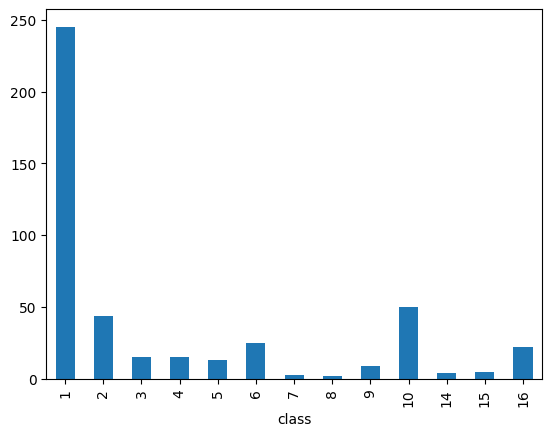

In [4]:
df.groupby(['class']).size().plot.bar()

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Columns: 280 entries, 0 to class
dtypes: float64(120), int64(155), object(5)
memory usage: 988.9+ KB
None


In [6]:
counter = 0
all_value = 0

for col in range(df.shape[1]):
    for row in range(df.shape[0]):
        if df.iat[row, col] == '?':
            counter += 1
        all_value += 1

print(counter)
print(all_value)
print(f'{counter/all_value*100:.3}')

408
126560
0.322


In [7]:
for col in range(df.shape[1]):
    for row in range(df.shape[0]):
        if df.iat[row, col] == '?':
            df.iat[row, col] = 0
df = df.astype(float)

In [8]:
(df[274]==0).all()

np.True_

In [9]:
pd.DataFrame(df).corr().style.background_gradient(cmap='Blues')

/Users/irene/big-data-env/lib/python3.13/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/Users/irene/big-data-env/lib/python3.13/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


In [10]:
s_df = (df-df.mean())/df.std()

s_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,class
count,4.520000e+02,4.520000e+02,4.520000e+02,4.520000e+02,4.520000e+02,4.520000e+02,4.520000e+02,4.520000e+02,4.520000e+02,4.520000e+02,...,4.520000e+02,4.520000e+02,4.520000e+02,4.520000e+02,0.0,4.520000e+02,4.520000e+02,4.520000e+02,4.520000e+02,4.520000e+02
mean,-2.357996e-17,-5.501990e-17,3.694193e-16,2.397296e-16,2.829595e-16,-1.346023e-16,2.672395e-16,3.143994e-16,-3.929993e-17,5.894990e-17,...,-2.554495e-17,-7.073987e-17,5.501990e-17,2.947495e-17,NaN,2.240096e-16,3.929993e-17,-2.397296e-16,1.336198e-16,1.375498e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,NaN,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.822146e+00,-1.106294e+00,-1.646153e+00,-3.747278e+00,-2.207725e+00,-3.459963e+00,-4.049910e+00,-1.738529e+00,-3.484945e+00,-4.527196e+00,...,-6.961535e+00,-2.605346e+00,-1.355488e+01,-7.945836e-02,NaN,-3.783329e+00,-5.064574e+00,-4.704271e+00,-3.680842e+00,-6.536119e-01
25%,-6.359066e-01,-1.106294e+00,-1.664782e-01,-5.527372e-01,-5.805861e-01,-2.933092e-01,-5.154335e-01,-6.159759e-01,-4.260881e-01,-6.587287e-01,...,-2.660305e-01,-7.048966e-01,-3.209596e-01,-7.945836e-02,NaN,-3.303968e-01,-5.065350e-01,-5.832458e-01,-6.447106e-01,-6.536119e-01
50%,3.211106e-02,9.019187e-01,-5.886557e-02,-1.026798e-02,-1.900728e-01,4.119650e-02,-6.229204e-03,-2.230825e-01,3.854838e-02,1.391770e-01,...,5.082795e-01,-7.141339e-02,1.784337e-01,-7.945836e-02,NaN,-4.265237e-02,8.951629e-02,-9.079630e-02,-8.506739e-02,-6.536119e-01
75%,7.001287e-01,9.019187e-01,1.025535e-01,6.527500e-01,3.306115e-01,4.426034e-01,5.029751e-01,2.540024e-01,4.644651e-01,7.114679e-01,...,5.082795e-01,6.196592e-01,7.277663e-01,-7.945836e-02,NaN,5.328364e-01,6.154439e-01,4.812597e-01,6.300322e-01,4.809218e-01
max,2.218351e+00,9.019187e-01,1.651349e+01,6.499363e+00,6.448653e+00,8.225436e+00,4.247124e+00,5.922893e+00,4.452595e+00,2.978621e+00,...,5.082795e-01,4.190201e+00,7.277663e-01,1.588284e+01,NaN,5.424491e+00,3.350267e+00,5.144720e+00,4.673251e+00,2.749989e+00


In [11]:
n_df = (df-df.min())/(df.max()-df.min())
n_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,class
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,...,452.000000,452.000000,452.000000,452.000000,0.0,452.000000,452.000000,452.000000,452.000000,452.000000
mean,0.559894,0.550885,0.090649,0.365708,0.255040,0.296093,0.488115,0.226920,0.439046,0.603158,...,0.931956,0.383390,0.949045,0.004978,NaN,0.410882,0.601862,0.477640,0.440603,0.192035
std,0.198393,0.497955,0.055067,0.097593,0.115522,0.085577,0.120525,0.130524,0.125984,0.133230,...,0.133872,0.147155,0.070015,0.062648,NaN,0.108603,0.118838,0.101533,0.119702,0.293806
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.433735,0.000000,0.081481,0.311765,0.187970,0.270992,0.425993,0.146520,0.385366,0.515396,...,0.896341,0.279661,0.926573,0.000000,NaN,0.375000,0.541667,0.418421,0.363430,0.000000
50%,0.566265,1.000000,0.087407,0.364706,0.233083,0.299618,0.487365,0.197802,0.443902,0.621701,...,1.000000,0.372881,0.961538,0.000000,NaN,0.406250,0.612500,0.468421,0.430421,0.000000
75%,0.698795,1.000000,0.096296,0.429412,0.293233,0.333969,0.548736,0.260073,0.497561,0.697947,...,1.000000,0.474576,1.000000,0.000000,NaN,0.468750,0.675000,0.526504,0.516019,0.333333
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
feature = n_df.drop('class', axis=1)
feature.fillna(0, inplace=True)

In [13]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=279)
pca.fit(feature)
X = pca.transform(feature)

total_variation = np.sum(pca.singular_values_ ** 2)
print(f'total variance {total_variation:4.2f}')

total variance 1785.29


In [18]:
pca = decomposition.PCA(n_components=0.9)
pca.fit(feature)
X = pca.transform(feature)

variation = np.sum(pca.singular_values_ ** 2)
print(f'total variance {100*variation/total_variation:4.2f}')

total variance 90.05


In [15]:
!pip install tqdm


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [16]:
from tqdm import tqdm

variance = []

for component in tqdm(range(279)):
    pca = decomposition.PCA(n_components=component+1)
    pca.fit(feature)
    X = pca.transform(feature)
    variance.append(np.sum(pca.singular_values_ ** 2))

100%|██████████| 279/279 [00:02<00:00, 112.76it/s]


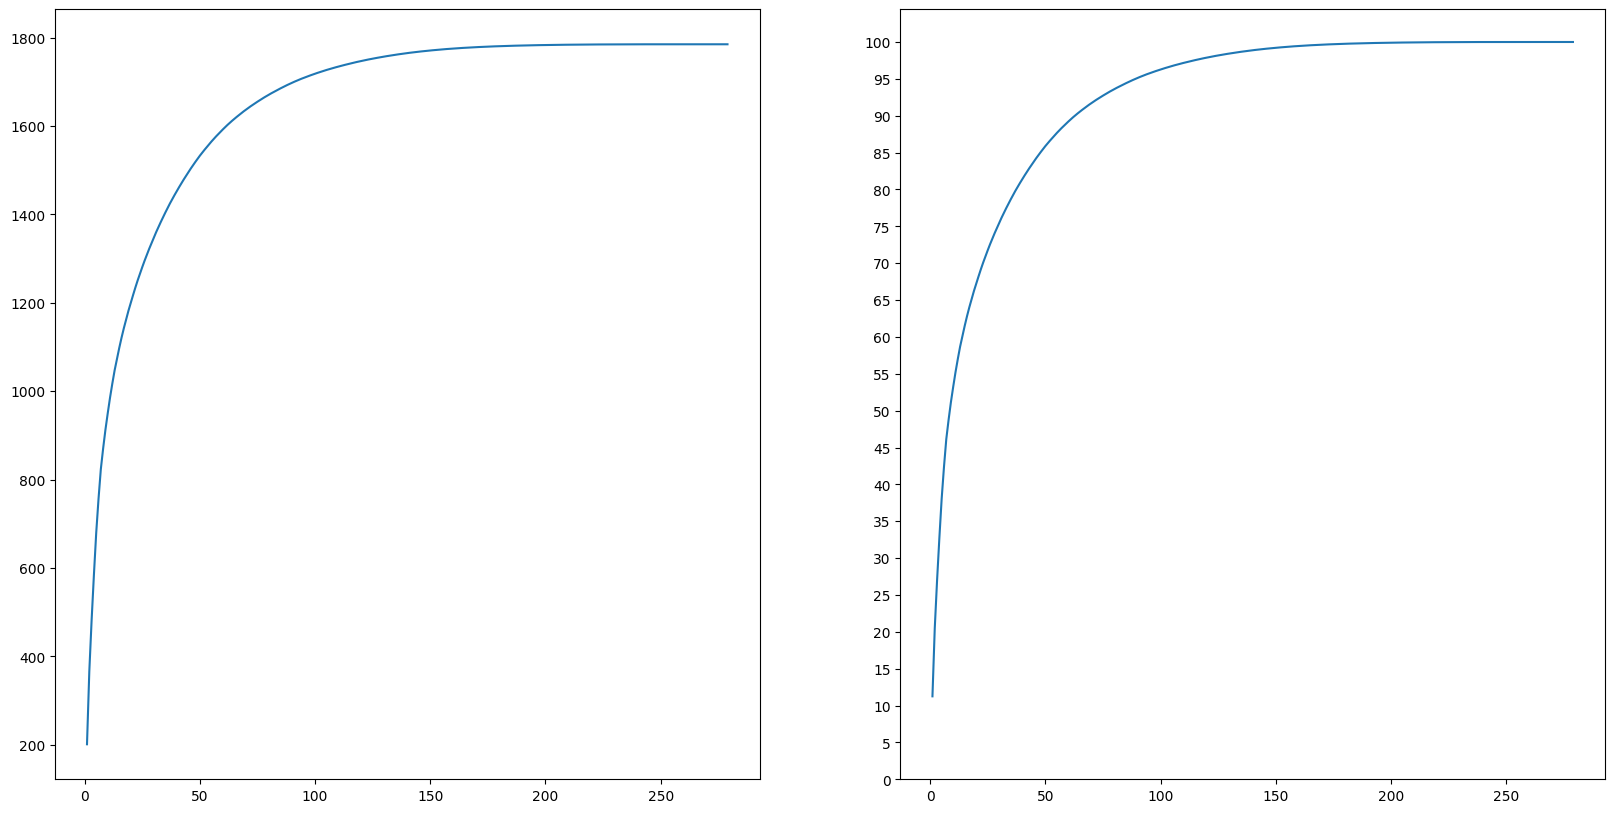

In [17]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(1,2, figsize=(20,10))

axs[0].plot([x+1 for x in range(279)], variance)
axs[1].plot([x+1 for x in range(279)], [100*v/total_variation for v in variance])
axs[1].set_yticks(np.arange(0, 105, 5))


In [43]:
variance_perc = [100*v/total_variation for v in variance]

for idx, var in enumerate(variance_perc):
    print(idx+1, var)

1 11.250341120488407
2 20.47447469068137
3 26.952422270093457
4 32.71874149437789
5 38.05100890285019
6 42.354314178701884
7 46.122022827927935
8 48.741560069277256
9 51.120793443480686
10 53.216497970653144
11 55.20251201647698
12 56.994067261182146
13 58.675139458129685
14 60.119942353220644
15 61.503421112573164
16 62.808299314672446
17 64.01276466331525
18 65.13374454641443
19 66.2232437579451
20 67.22962112493582
21 68.20430184862195
22 69.16189653780093
23 70.06997354749059
24 70.92553137970415
25 71.75803970964806
26 72.5636886162447
27 73.32318997550483
28 74.07316272832895
29 74.78393803830801
30 75.48213522046147
31 76.17042293320851
32 76.82166902542113
33 77.4514098653967
34 78.0715512673087
35 78.66543025025334
36 79.25419083592654
37 79.81877493110417
38 80.35818891993664
39 80.88505426924445
40 81.40167019489039
41 81.89856410276872
42 82.38462095848406
43 82.86347695231753
44 83.3254559444702
45 83.78287773126084
46 84.22497428882396
47 84.65838033693242
48 85.071895453

100%|██████████| 279/279 [00:03<00:00, 90.39it/s] 


([<matplotlib.axis.YTick at 0x112f1ae90>,
 [Text(0, 0, '0'),
  Text(0, 5, '5'),
  Text(0, 10, '10'),
  Text(0, 15, '15'),
  Text(0, 20, '20'),
  Text(0, 25, '25'),
  Text(0, 30, '30'),
  Text(0, 35, '35'),
  Text(0, 40, '40'),
  Text(0, 45, '45'),
  Text(0, 50, '50'),
  Text(0, 55, '55'),
  Text(0, 60, '60'),
  Text(0, 65, '65'),
  Text(0, 70, '70'),
  Text(0, 75, '75'),
  Text(0, 80, '80'),
  Text(0, 85, '85'),
  Text(0, 90, '90'),
  Text(0, 95, '95'),
  Text(0, 100, '100')])

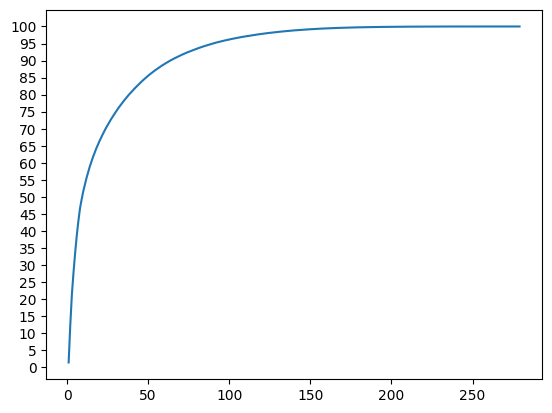

In [44]:
from sklearn.decomposition import TruncatedSVD

variance = []

for component in tqdm(range(279)):

    svd = decomposition.TruncatedSVD(n_components=component+1, random_state=17)
    svd.fit(feature)
    X = svd.transform(feature)
    variance.append(svd.explained_variance_ratio_.sum()*100)

plt.plot([x+1 for x in range(279)], variance)
plt.yticks(np.arange(0, 105, 5))

In [45]:
for idx, var in enumerate(variance):
    print(idx+1, var)

1 1.3806617818977653
2 12.26199592113709
3 21.371928984060883
4 27.799785803270893
5 33.49956563086269
6 38.58303527636377
7 42.88319810113481
8 46.60788843834214
9 49.20371929054723
10 51.57916155699957
11 53.60559249513502
12 55.504531769069686
13 57.1846948053332
14 58.8327975739074
15 60.27010188713919
16 61.65238161910636
17 62.9457669623398
18 64.15019115719709
19 65.27011371263927
20 66.34182638747997
21 67.35836299148094
22 68.33316047058221
23 69.28994908580624
24 70.19365962835474
25 71.03758828872313
26 71.87276847351684
27 72.66076268212102
28 73.41963214301754
29 74.1730682253632
30 74.87635466113586
31 75.58972261842679
32 76.26935742927914
33 76.91569127141197
34 77.54029370544315
35 78.15488038929126
36 78.73784366067923
37 79.32810946888421
38 79.89632987572335
39 80.41866536237222
40 80.94713097073132
41 81.47119494068598
42 81.96102716430622
43 82.44234805926625
44 82.92932170612983
45 83.39474245046465
46 83.84705474001842
47 84.28695279199742
48 84.7051541932272
49